# Code to AI — Week 6, Day 3: Build & Ship — Netflix Data Cleaning Project
**Pandas II — Data Cleaning**

---

Welcome back! This is it — everything from Day 1 and Day 2 applied to one real, genuinely messy dataset.

The Netflix titles dataset lists thousands of movies and TV shows on the platform. It has missing directors, missing countries, dates stored as text, durations that mix minutes and seasons, and duplicate rows. Exactly the kind of file you get handed in a real job.

By the end you will have a cleaned CSV, five real insights, a chart, and a repo on your GitHub profile.

**By the end of this notebook you will be able to:**
- Run a full cleaning workflow on real data, start to finish
- Document every cleaning decision as you make it
- Pull genuine insights out of the cleaned result
- Save a cleaned CSV and ship the project to GitHub

## Getting the dataset

The file is `netflix_titles.csv` and it belongs in a `data/` folder next to this notebook:

```
Week6/Day3/
├── week6_day3_class.ipynb
└── data/
    └── netflix_titles.csv
```

You can download it from Kaggle: search for **"Netflix Movies and TV Shows"**
(by Shivam Bansal). A copy is also shared in the WhatsApp group.

> **Working in Google Colab?**
> Colab does not see the files on your computer. Run the cell below **first** to upload
> `netflix_titles.csv`, then skip the `read_csv('data/...')` cell and use this one instead.
>
> If you are running locally in VS Code, ignore this and use the normal loading cell.

In [ ]:
# ONLY run this if you are on Google Colab.
# It opens a file picker - choose your netflix_titles.csv

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('netflix_titles.csv')
# print("Shape:", df.shape)

---
## 1. Load and take a first look

Never start cleaning before you have looked at what you have.

In [40]:
import pandas as pd

In [41]:


# The CSV lives in the data/ folder next to this notebook
df = pd.read_csv('data/netflix_titles.csv')

print("Loaded successfully!")
print("Shape:", df.shape)

Loaded successfully!
Shape: (8612, 12)


In [42]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8365,TV Show,Lost Kingdom,NaN,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,"June 16, 2020",2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.
1,s5294,TV Show,Lost Summer,NaN,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,"November 14, 2009",2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,"January 5, 2008",2003,NR,97 min,Horror Movies,A sweeping story about survival.
3,s7760,Movie,Endless Empire Forever,Yuki Sato,"Maria Khan, Fatima Garcia, Chen Tanaka",India,"September 15, 2014",2011,R,102 min,"Documentaries, International Movies",A hilarious story about family.
4,s3313,TV Show,Burning Dream,NaN,"Raj Wilson, Elena Wang, John Brown, Chen Wang,...",India,"April 10, 2008",2003,TV-Y7,1 Season,Docuseries,A sweeping story about ambition.


In [44]:
df.sample(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2773,s1215,Movie,Endless Empire II,Hiroshi Novak,NaN,United States,"January 26, 2012",2009,TV-MA,92 min,Documentaries,A heartfelt story about family.
1080,s1268,TV Show,Dark Garden Forever,NaN,"Diego Rossi, Raj Wilson, Yuki Rossi, Grace Ali...",South Korea,"November 12, 2021",2021,TV-Y,2 Seasons,TV Comedies,A sweeping story about love.


In [45]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
print("Column names:")
print(list(df.columns))

Rows: 8612
Columns: 12

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8612 non-null   str  
 1   type          8612 non-null   str  
 2   title         8612 non-null   str  
 3   director      6214 non-null   str  
 4   cast          7840 non-null   str  
 5   country       7835 non-null   str  
 6   date_added    8601 non-null   str  
 7   release_year  8612 non-null   int64
 8   rating        8608 non-null   str  
 9   duration      8609 non-null   str  
 10  listed_in     8612 non-null   str  
 11  description   8612 non-null   str  
dtypes: int64(1), str(11)
memory usage: 807.5 KB


### What each column means

| Column | Meaning |
|--------|---------|
| `show_id` | Unique ID for each title |
| `type` | Movie or TV Show |
| `title` | Name of the title |
| `director` | Director's name |
| `cast` | Actors, comma-separated in one string |
| `country` | Country of production |
| `date_added` | When it was added to Netflix (stored as text) |
| `release_year` | Year it was originally released |
| `rating` | Age rating (TV-MA, PG-13, ...) |
| `duration` | "90 min" for movies, "2 Seasons" for shows |
| `listed_in` | Genres, comma-separated |
| `description` | Short summary |

Two things should already worry you: `date_added` is text, and `duration` mixes two
completely different units in one column.

---
## 2. The missing-value report

Straight from Day 1 — this is the reusable snippet.

In [47]:
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0]
report = report.sort_values('missing_percent', ascending=False)

report

,missing_count,missing_percent
director,2398,27.8
cast,772,9.0
country,777,9.0
date_added,11,0.1
rating,4,0.0
duration,3,0.0


In [49]:
df.isnull().sum().sum()

np.int64(3965)

In [50]:
print("Total missing values:", df.isnull().sum().sum())
print("Total rows:", len(df))

Total missing values: 3965
Total rows: 8612


---
## 3. Cleaning decisions

Before touching anything, decide what to do with each problem column — and write it down.
This markdown cell *is* part of the deliverable. In a real job this is what your manager reads.

| Column | Problem | Decision | Why |
|--------|---------|----------|-----|
| `director` | Heavily missing | Fill with `"Unknown"` | TV shows often have no single director. The gap is real information, not an error — deleting these rows would throw away most of the TV shows. |
| `cast` | ~9% missing | Fill with `"Unknown"` | Documentaries and stand-up often have no cast list. Same reasoning. |
| `country` | ~9% missing | Fill with `"Unknown"` | We want honest counts. Dropping would silently bias the country analysis. |
| `date_added` | A few missing | Drop those rows | Very few rows, and we need this column for the "added per year" insight. |
| `rating` | A few missing | Drop those rows | Tiny number of rows; no sensible way to guess an age rating. |
| `duration` | A few missing | Drop those rows | Tiny number, and duration is central to our analysis. |
| Duplicates | Exact repeats | Remove | Same title counted twice would inflate every number. |
| Text columns | Stray whitespace | `.str.strip()` | `"India "` and `"India"` must count as one country. |

Notice the pattern: **fill when the gap is meaningful and the column matters; drop when
the number of affected rows is tiny.**

Now let's execute that plan.

---
## 4. Make a working copy

The golden rule, every time.

In [51]:
clean = df.copy()
print("Working copy created with", len(clean), "rows")

Working copy created with 8612 rows


---
## 5. Remove duplicates

Do this early, before the row counts feed into anything else.

In [52]:
print("Duplicate rows found:", clean.duplicated().sum())

Duplicate rows found: 12


In [54]:
clean[clean.duplicated(keep=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
108,s7184,Movie,Lost Story 2,Ahmed Ali,"John Wang, Elena Sato, Aarav Khan, Grace Wilso...",Egypt,"May 16, 2021",2019,G,111 min,"Dramas, International Movies",A sweeping story about survival.
215,s438,Movie,Last Journey 2,Aarav Rossi,"Chen Sato, Sofia Wang, Fatima Khan, Diego Brow...",France,"July 17, 2008",2004,TV-G,78 min,Documentaries,A gripping story about survival.
476,s3018,Movie,Frozen Night,John Brown,"Elena Kumar, Grace Sharma, Diego Tanaka, Maria...",France,"June 19, 2021",2020,TV-MA,87 min,"Dramas, Independent Movies",A chilling story about revenge.
642,s1050,Movie,Silent Night Forever,Chen Smith,"Sofia Wang, Grace Wang, Raj Smith, Raj Rossi, ...",United Kingdom,"December 2, 2016",2015,TV-PG,82 min,Thrillers,A hilarious story about love.
817,s4445,TV Show,Hidden Summer Forever,NaN,"Sofia Smith, Chen Wang, Maria Smith, Grace Wil...",Egypt,"April 28, 2008",1998,TV-14,3 Seasons,Docuseries,A heartfelt story about survival.
1869,s370,TV Show,Dark Road,NaN,"Ahmed Wang, Aarav Smith, Hiroshi Garcia, Ahmed...",United States,"August 14, 2013",2012,TV-Y,1 Season,"Crime TV Shows, TV Dramas",A heartfelt story about survival.
1957,s3753,Movie,Crimson Summer,Grace Rossi,"Elena Brown, Yuki Tanaka, Grace Novak",United States,"December 9, 2020",2019,PG,56 min,Comedies,A gripping story about family.
2184,s4507,Movie,Lost Story,John Wang,"Fatima Lopez, Raj Lopez, Sofia Hassan, Hiroshi...",United States,"April 15, 2008",2007,NR,110 min,"Dramas, Independent Movies",A sweeping story about love.
2387,s438,Movie,Last Journey 2,Aarav Rossi,"Chen Sato, Sofia Wang, Fatima Khan, Diego Brow...",France,"July 17, 2008",2004,TV-G,78 min,Documentaries,A gripping story about survival.
2435,s1050,Movie,Silent Night Forever,Chen Smith,"Sofia Wang, Grace Wang, Raj Smith, Raj Rossi, ...",United Kingdom,"December 2, 2016",2015,TV-PG,82 min,Thrillers,A hilarious story about love.


In [55]:
rows_before = len(clean)
clean = clean.drop_duplicates()
rows_after = len(clean)

print("Before:", rows_before)
print("After: ", rows_after)
print("Removed:", rows_before - rows_after, "duplicate rows")

Before: 8612
After:  8600
Removed: 12 duplicate rows


---
## 6. Strip whitespace from text columns

Invisible spaces would break every count we are about to make.

In [56]:
clean.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8365,TV Show,Lost Kingdom,NaN,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,"June 16, 2020",2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.


In [ ]:
# clean['type'] = clean['type'].str.strip()
# clean['director'] = clean['director'].str.strip()

In [57]:
text_columns = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']

for col in text_columns:
    clean[col] = clean[col].str.strip()

print("Whitespace stripped from:", text_columns)

Whitespace stripped from: ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']


Let's prove that mattered. If `country` had stray spaces, the unique count drops after stripping:

In [58]:
print("Unique countries in the raw data: ", df['country'].nunique())
print("Unique countries after stripping: ", clean['country'].nunique())

Unique countries in the raw data:  32
Unique countries after stripping:  16


---
## 7. Fill the columns we are keeping

`director`, `cast` and `country` all get `"Unknown"` — an honest label for a real gap.

In [59]:
for col in ['director', 'cast', 'country']:
    print(f"{col}: {clean[col].isnull().sum()} missing before")
    clean[col] = clean[col].fillna('Unknown')
    print(f"{col}: {clean[col].isnull().sum()} missing after")
    print()

director: 2396 missing before
director: 0 missing after

cast: 771 missing before
cast: 0 missing after

country: 776 missing before
country: 0 missing after



In [61]:
clean.info()

<class 'pandas.DataFrame'>
Index: 8600 entries, 0 to 8611
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8600 non-null   str  
 1   type          8600 non-null   str  
 2   title         8600 non-null   str  
 3   director      8600 non-null   str  
 4   cast          8600 non-null   str  
 5   country       8600 non-null   str  
 6   date_added    8589 non-null   str  
 7   release_year  8600 non-null   int64
 8   rating        8596 non-null   str  
 9   duration      8597 non-null   str  
 10  listed_in     8600 non-null   str  
 11  description   8600 non-null   str  
dtypes: int64(1), str(11)
memory usage: 873.4 KB


In [62]:
clean['country'].value_counts()

country
United States     2666
India             1327
Unknown            776
United Kingdom     698
Canada             440
Japan              356
France             334
South Korea        315
Spain              266
Mexico             258
Australia          220
Germany            189
Turkey             174
China              161
Egypt              157
Nigeria            142
Pakistan           121
Name: count, dtype: int64

---
## 8. Drop the rows we cannot fix

`date_added`, `rating` and `duration` are each missing in only a handful of rows,
and none of them can be sensibly guessed.

In [63]:
rows_before = len(clean)

clean = clean.dropna(subset=['date_added', 'rating', 'duration'])
# clean.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

print("Before:", rows_before)
print("After: ", len(clean))
print("Dropped:", rows_before - len(clean), "rows")
print()
print("That is", round((rows_before - len(clean)) / rows_before * 100, 2), "% of the data - acceptable.")

Before: 8600
After:  8582
Dropped: 18 rows

That is 0.21 % of the data - acceptable.


Always print the percentage you lost. If it had come out at 30% you would need to
rethink the plan rather than quietly carry on.

---
## 9. Convert `date_added` to a real date

It is text like `"September 25, 2021"`. Pandas can parse that.

In [65]:
clean['date_added'].head(1)

0    June 16, 2020
Name: date_added, dtype: str

In [66]:
print("Type before:", clean['date_added'].dtype)
print("Example value:", clean['date_added'].iloc[0])

Type before: str
Example value: June 16, 2020


In [67]:
clean['date_added'] = pd.to_datetime(clean['date_added'], format='mixed')

print("Type after:", clean['date_added'].dtype)
print("Example value:", clean['date_added'].iloc[0])

Type after: datetime64[us]
Example value: 2020-06-16 00:00:00


Now `.dt` unlocks the year — which gives us one of our best insights.

In [68]:
clean['year_added'] = clean['date_added'].dt.year
clean['month_added'] = clean['date_added'].dt.month_name()

clean[['title', 'date_added', 'year_added', 'month_added']].head()

,title,date_added,year_added,month_added
0,Lost Kingdom,2020-06-16,2020,June
1,Lost Summer,2009-11-14,2009,November
2,Frozen Empire II,2008-01-05,2008,January
3,Endless Empire Forever,2014-09-15,2014,September
4,Burning Dream,2008-04-10,2008,April


---
## 10. Split the `duration` column

This column is a genuine design flaw in the raw data: `"90 min"` and `"2 Seasons"` are
different units living in the same place. You cannot average it, sort it, or filter it
until you split it.

In [71]:
clean['duration'].head(3).tolist()

['1 Season', '1 Season', '97 min']

In [70]:
print(clean['duration'].head(10).tolist())

['1 Season', '1 Season', '97 min', '102 min', '1 Season', '120 min', '97 min', '91 min', '119 min', '2 Seasons']


In [74]:
clean['duration'].info()

<class 'pandas.Series'>
Index: 8582 entries, 0 to 8611
Series name: duration
Non-Null Count  Dtype
--------------  -----
8582 non-null   str  
dtypes: str(1)
memory usage: 134.1 KB


In [75]:
parts = clean['duration'].str.split(' ', expand=True)
print(parts)


        0       1
0       1  Season
1       1  Season
2      97     min
3     102     min
4       1  Season
...   ...     ...
8607  109     min
8608  107     min
8609   84     min
8610   92     min
8611    1  Season

[8582 rows x 2 columns]


In [76]:
clean['duration_number'] = pd.to_numeric(parts[0])
clean['duration_unit'] = parts[1]

clean[['title', 'type', 'duration', 'duration_number', 'duration_unit']].head(10)

,title,type,duration,duration_number,duration_unit
0,Lost Kingdom,TV Show,1 Season,1,Season
1,Lost Summer,TV Show,1 Season,1,Season
2,Frozen Empire II,Movie,97 min,97,min
3,Endless Empire Forever,Movie,102 min,102,min
4,Burning Dream,TV Show,1 Season,1,Season
5,Frozen Horizon,Movie,120 min,120,min
6,Burning Story 2,Movie,97 min,97,min
7,Silent Promise,Movie,91 min,91,min
8,Wild Dream 2,Movie,119 min,119,min
9,Crimson Shadow,TV Show,2 Seasons,2,Seasons


In [77]:
print(clean['duration_unit'].value_counts())

duration_unit
min        6026
Seasons    1627
Season      929
Name: count, dtype: int64


`min` for movies, `Season`/`Seasons` for shows. Now the numbers are usable — but only
within their own group. Averaging minutes and seasons together would be meaningless,
so every duration insight below filters by `type` first.

---
## 11. Confirm the data is clean

In [78]:
print("Missing values remaining:")
print(clean.isnull().sum())
print()
print("TOTAL missing:", clean.isnull().sum().sum())

Missing values remaining:
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added         0
month_added        0
duration_number    0
duration_unit      0
dtype: int64

TOTAL missing: 0


In [79]:
print("=== SUMMARY ===")
print("Original rows: ", len(df))
print("Cleaned rows:  ", len(clean))
print("Rows removed:  ", len(df) - len(clean))
print("Original columns:", len(df.columns))
print("Cleaned columns: ", len(clean.columns), "(we added year_added, month_added, duration_number, duration_unit)")

=== SUMMARY ===
Original rows:  8612
Cleaned rows:   8582
Rows removed:   30
Original columns: 12
Cleaned columns:  16 (we added year_added, month_added, duration_number, duration_unit)


---
## 12. Insights

The cleaning was never the goal — it was the price of admission. Now we can ask real
questions and trust the answers.

### Insight 1 — Movies vs TV Shows

In [80]:
type_counts = clean['type'].value_counts()
print(type_counts)
print()

type_percent = (clean['type'].value_counts(normalize=True) * 100).round(1)
print("As percentages:")
print(type_percent)

type
Movie      6026
TV Show    2556
Name: count, dtype: int64

As percentages:
type
Movie      70.2
TV Show    29.8
Name: proportion, dtype: float64


### Insight 2 — Top 10 countries

Remember `Unknown` is in here as a real category. That is deliberate — it tells you how
much you *don't* know, which is itself a finding.

In [83]:
top_countries = clean['country'].value_counts().head(10)
print(top_countries)

country
United States     2657
India             1322
Unknown            776
United Kingdom     697
Canada             440
Japan              355
France             334
South Korea        315
Spain              265
Mexico             258
Name: count, dtype: int64


### Insight 3 — Titles added per year

This is the insight that only became possible after the date conversion.

In [86]:
per_year = clean['year_added'].value_counts().sort_index()
print(per_year)

year_added
2008    1474
2009     320
2010     376
2011     437
2012     439
2013     484
2014     445
2015     470
2016     464
2017     475
2018     445
2019     424
2020     404
2021    1925
Name: count, dtype: int64


### Insight 4 — Average movie duration

Filter to movies first, so we are averaging minutes with minutes.

In [87]:
movies = clean[clean['type'] == 'Movie']

print("Number of movies:", len(movies))
print("Average duration:", round(movies['duration_number'].mean(), 1), "minutes")
print("Median duration: ", movies['duration_number'].median(), "minutes")
print("Shortest:", movies['duration_number'].min(), "minutes")
print("Longest: ", movies['duration_number'].max(), "minutes")

Number of movies: 6026
Average duration: 98.7 minutes
Median duration:  98.0 minutes
Shortest: 45 minutes
Longest:  183 minutes


### Insight 5 — Most common ratings

In [88]:
print(clean['rating'].value_counts().head(10))

rating
TV-14    1184
TV-G     1120
TV-MA    1118
TV-PG    1084
NR        658
R         658
G         657
PG        643
PG-13     642
TV-Y      422
Name: count, dtype: int64


---
## 13. One chart

Week 7 is all about visualisation. For today, one clear bar chart of titles added per year.

<Axes: title={'center': 'Netflix Titles Added Per Year'}, xlabel='Year', ylabel='Number of Movies and TV Shows'>

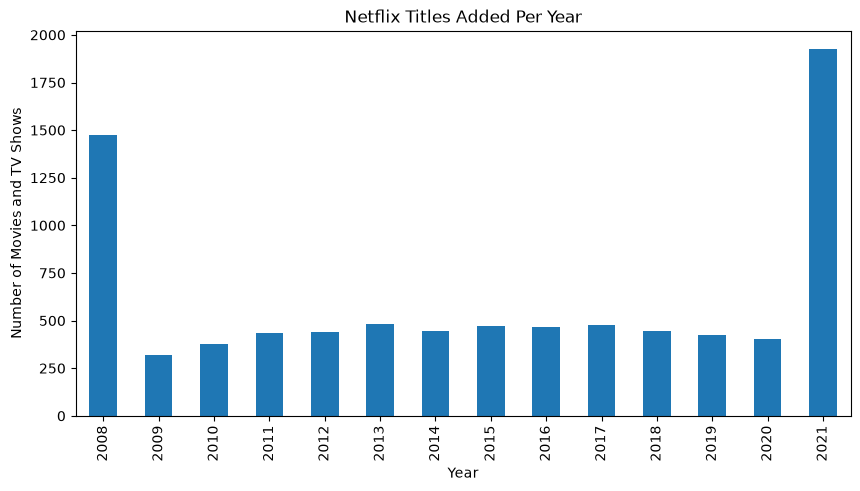

In [89]:
per_year.plot(
    kind='bar',
    title='Netflix Titles Added Per Year',
    xlabel='Year',
    ylabel='Number of Movies and TV Shows',
    figsize=(10, 5)
)

In [90]:
per_year = clean['year_added'].value_counts()
print(per_year)

year_added
2021    1925
2008    1474
2013     484
2017     475
2015     470
2016     464
2014     445
2018     445
2012     439
2011     437
2019     424
2020     404
2010     376
2009     320
Name: count, dtype: int64


<Axes: title={'center': 'Netflix Titles Added Per Year'}, xlabel='Year', ylabel='Number of Movies and TV Shows'>

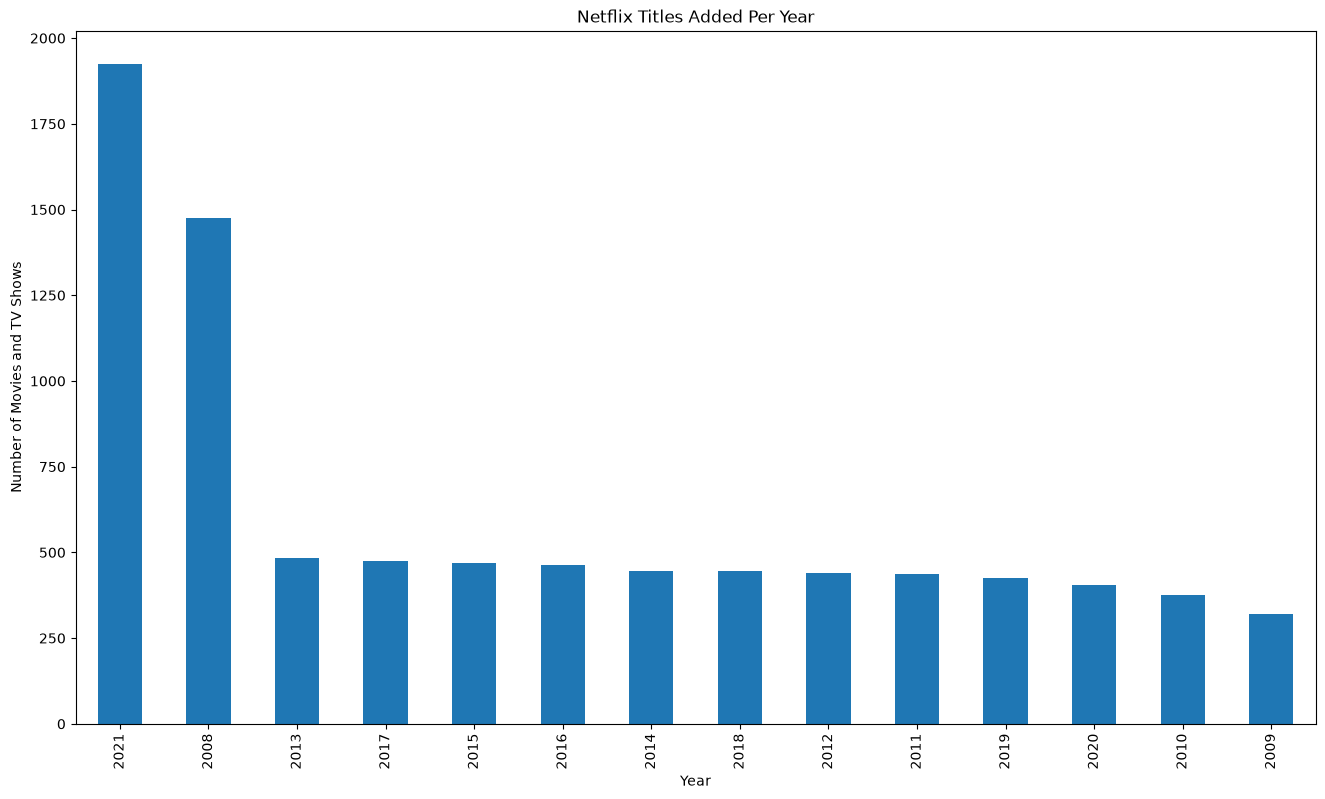

In [91]:
per_year.plot(
    kind='bar',
    title='Netflix Titles Added Per Year',
    xlabel='Year',
    ylabel='Number of Movies and TV Shows',
    figsize=(16, 9)
)

---
## 14. Save the cleaned dataset

`index=False` stops pandas writing its row numbers as an extra unnamed column —
a small detail that trips up a lot of beginners.

In [93]:
clean.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_number,duration_unit
0,s8365,TV Show,Lost Kingdom,Unknown,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,2020-06-16,2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.,2020,June,1,Season
1,s5294,TV Show,Lost Summer,Unknown,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,2009-11-14,2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.,2009,November,1,Season
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,2008-01-05,2003,NR,97 min,Horror Movies,A sweeping story about survival.,2008,January,97,min


In [95]:
clean.info()

<class 'pandas.DataFrame'>
Index: 8582 entries, 0 to 8611
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8582 non-null   str           
 1   type             8582 non-null   str           
 2   title            8582 non-null   str           
 3   director         8582 non-null   str           
 4   cast             8582 non-null   str           
 5   country          8582 non-null   str           
 6   date_added       8582 non-null   datetime64[us]
 7   release_year     8582 non-null   int64         
 8   rating           8582 non-null   str           
 9   duration         8582 non-null   str           
 10  listed_in        8582 non-null   str           
 11  description      8582 non-null   str           
 12  year_added       8582 non-null   int32         
 13  month_added      8582 non-null   str           
 14  duration_number  8582 non-null   int64         
 15  dur

In [ ]:
clean.to_csv()

In [96]:
clean.to_csv('netflix_clean.csv', index=False)

print("Saved netflix_clean.csv")
print("Rows:", len(clean), "| Columns:", len(clean.columns))

Saved netflix_clean.csv
Rows: 8582 | Columns: 16


In [97]:
# Read it back to prove it saved correctly
check = pd.read_csv('netflix_clean.csv')
print("Reloaded shape:", check.shape)
check.head(3)

Reloaded shape: (8582, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_number,duration_unit
0,s8365,TV Show,Lost Kingdom,Unknown,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,2020-06-16,2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.,2020,June,1,Season
1,s5294,TV Show,Lost Summer,Unknown,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,2009-11-14,2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.,2009,November,1,Season
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,2008-01-05,2003,NR,97 min,Horror Movies,A sweeping story about survival.,2008,January,97,min


---
## 15. Ship it to GitHub

### Your repo structure

```
netflix-data-cleaning/
├── README.md
├── netflix_data_cleaning.ipynb
├── netflix_clean.csv
└── data/
    └── netflix_titles.csv
```

### README template

Copy this into `README.md` and fill in your actual numbers:

```markdown
# Netflix Data Cleaning Project

Cleaning and exploring the Netflix Movies and TV Shows dataset.

## Problem
The raw dataset has missing values in several columns, dates stored as
text, duplicate rows, and a duration column that mixes minutes with seasons.

## Approach
- Built a missing-value report to size up the damage
- Filled director, cast and country with "Unknown" (the gaps are meaningful)
- Dropped the few rows missing date_added, rating or duration
- Removed duplicate rows and stripped stray whitespace
- Converted date_added to a real datetime and extracted the year
- Split duration into a number and a unit

## Results
- Started with X rows, finished with Y rows
- Zero missing values remaining
- Movies make up Z% of the catalogue
- Most titles come from [country]
- Average movie length is N minutes

## Tools
Python, pandas

## What I learned
[Write 2-3 honest sentences here. This is the part people actually read.]
```

### The commands

```bash
git init
git add .
git commit -m "Netflix data cleaning project - Week 6"
git branch -M main
git remote add origin https://github.com/YOUR-USERNAME/netflix-data-cleaning.git
git push -u origin main
```

Then post your repo link in the WhatsApp group. 🎉

---
## What you built today

A complete, honest data-cleaning pipeline:

1. Loaded and inspected real data
2. Reported exactly what was missing
3. **Wrote down every decision before making it**
4. Removed duplicates and whitespace
5. Filled what deserved filling, dropped what deserved dropping
6. Converted a text column into real dates
7. Split a broken column into usable pieces
8. Produced five insights and a chart
9. Saved a clean CSV and shipped to GitHub

Step 3 is the one that separates a data analyst from someone who runs pandas commands.
Anyone can call `.fillna()`. Being able to say *why* is the job.

**Next week:** Data Visualisation, Storytelling & Streamlit — we turn these numbers into
charts people actually want to look at, and put a live web app on the internet. 🚀